In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def fixTime(ds):
    print("fix time:units")
    ds.time.encoding["units"] = "months since 1950-01-15"
    return xr.decode_cf(ds)

def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights


def anomaly(glbmean, normalise = False, detrend = False):
    
    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        linfit = glbmean.polyfit('time',1)
        slope = linfit.polyfit_coefficients.isel(degree = 0)*ns_century

        trend = xr.polyval(coord = glbmean.time, coeffs = linfit.polyfit_coefficients)
        glbmean = glbmean - trend.values +glbmean.mean(dim = 'time')
    
    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim    # detrended interannual annomaly
   

    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name

    return dataanom

def box_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = box_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights)
    return data_glbanom





# El-Nino

## 3.4

In [3]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(360-170.,360-120.), lat=slice(5,-5))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
nino34_index = anomaly(sst_boxmean, detrend = False)
nino34_index = nino34_index.rename('nino34_index')   # change variable name 


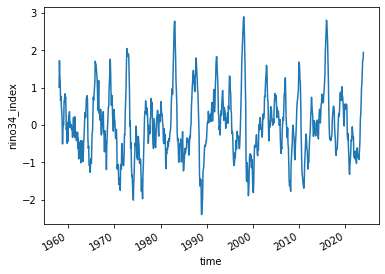

In [4]:
nino34_index.plot()

## 3

In [5]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(360-150.,360-90.), lat=slice(5,-5))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
nino3_index = anomaly(sst_boxmean, detrend = False)
nino3_index = nino3_index.rename('nino3_index')   # change variable name 


## West

In [6]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(130.,150.), lat=slice(15,0))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
ninowest_index = anomaly(sst_boxmean, detrend = False)
ninowest_index = ninowest_index.rename('ninowest_index')   # change variable name 


## 1+2

not detrended
normalised

In [7]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(360-90.,360-80.), lat=slice(0,-10))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
nino12_index = anomaly(sst_boxmean, normalise = True, detrend = False)
nino12_index = nino12_index.rename('nino12_index')   # change variable name 

# 4

not detrend
normalised

In [8]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(160.,360-150.), lat=slice(5,-5))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
nino4_index = anomaly(sst_boxmean, normalise = True, detrend = False)
nino4_index = nino4_index.rename('nino4_index')   # change variable name 


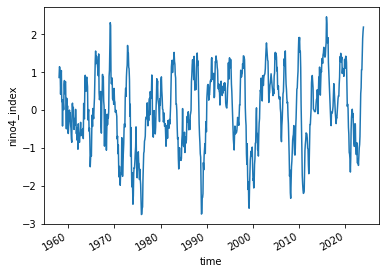

In [9]:
nino4_index.plot()

# TNI

- definded as normalised 1+2 index minus normalised 4 index

- not detrended

- not second normalised

- no running mean

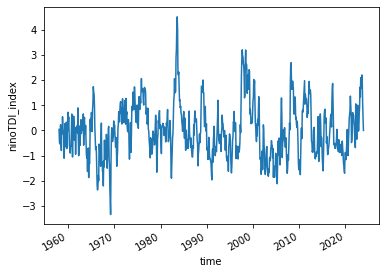

In [10]:
# compute difference between
ninoTDI_index = nino12_index-nino4_index
ninoTDI_index = ninoTDI_index.rename('ninoTDI_index')
ninoTDI_index.plot()

## east_west grad
nino12 minus nino.west

In [17]:
# compute difference between
ninoE_W_index = nino12_index-ninowest_index
ninoE_W_index = ninoE_W_index.rename('ninoE_W_index')


##  Save


In [19]:
nino_index = xr.Dataset()
nino_index['nino12'] = nino12_index
nino_index['nino3'] = nino3_index
nino_index['nino34'] = nino34_index
nino_index['nino4'] = nino4_index
nino_index['ninowest'] = ninowest_index

nino_index['ninoTDI'] = ninoTDI_index
nino_index['ninoE_W'] = ninoE_W_index

nino_index = encode_time(nino_index)
nino_index.to_netcdf('/data/jmex/output/drivers/indices/nino.nc')

# Detrend Nino Indices

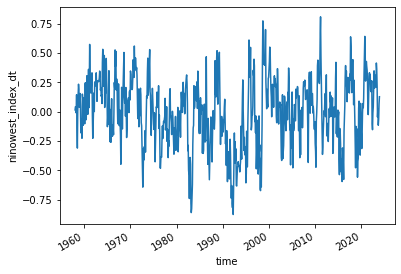

In [23]:
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
#select relv. area only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
sst = sst.sel(lon=slice(130.,150.), lat=slice(15,0))

#compute sst weights
sst_weights = build_weights(sst, sst.sst)

#compute box mean
sst_boxmean = box_mean(sst, sst.sst, sst_weights)

#compute anomalies as nino34 index
ninowest_index_dt = anomaly(sst_boxmean, detrend = True)
ninowest_index_dt = ninowest_index_dt.rename('ninowest_index_dt')   # change variable name 
ninowest_index_dt.plot()

In [26]:
nino_index_dt = xr.Dataset()
nino_index_dt['ninowest_dt'] = ninowest_index_dt

nino_index_dt = encode_time(nino_index_dt)
nino_index_dt.to_netcdf('/data/jmex/output/drivers/indices/nino_dt.nc')

# NAO

Several ways to define exists. The prefered ones use rotated principle components. 
The most basic one is usually based on weather station data (here on reanalysis) as the difference of normalised SLP anomalised located at Ponra Delgada (Azores) (or Lisbon/Gibraltar) minus the Iceland one (Jones et al 1997)


The more elaborat way is the PC of the first EOFof the NA pressure field over NA sector.
Good links are: (https://ajdawson.github.io/eofs/latest/examples/nao_standard.html)
(https://github.com/fredericferry/NAO/blob/main/NAO.ipynb)


For now we use the slp at Ponta Delgada (N37.7, W 25.7) and Akureyri (N65.7,18.1W)
the coordinates are approximated to match the available ERA5 points. 
The index is calculated as difference between normalised slp anomalies (Azores- Iceland)

In [16]:
#load slp set
#read in sst
fp = '/data/jmex/ERA5/monthly/era5_msl.nc'
slp = decode_time(fp)
#select relv. time only
#select relv. area only
slp = slp.sel(time = slice('1958-01-01', '2023-12-31'))
slp_azo = slp.sel(lat = 37.75, lon=360-25.75) 
slp_ice = slp.sel(lat = 65.75, lon = 360-18.)

#compute anomalies for both points
slp_azo_anom = anomaly(slp_azo.msl, normalise =True)
slp_ice_anom = anomaly(slp_ice.msl, normalise =True)

#subtract anomalies (A-I)
nao_index = slp_azo_anom-slp_ice_anom
nao_index = nao_index.rename('nao_index')


#save

nao_index = encode_time(nao_index)
nao_index.to_netcdf('/data/jmex/output/drivers/indices/nao.nc')

KeyboardInterrupt: 

In [ ]:
nao_index.plot()

# SAM


In [ ]:
#load slp data
fp = '/data/jmex/ERA5/monthly/era5_msl.nc'
slp = decode_time(fp)

#select time and space
#compute zonal means
slp = slp.sel(time = slice('1958-01-01', '2023-12-31'))
slp_S40 = slp.sel(lat = -40.).mean(dim = 'lon')
slp_S65 = slp.sel(lat = -65.).mean(dim = 'lon')

#compute anomalies of zonal means
slp_S40_anom = anomaly(slp_S40.msl, normalise = True)
slp_S65_anom = anomaly(slp_S65.msl, normalise = True)

#take the difference
sam_index = slp_S40_anom-slp_S65_anom
sam_index = sam_index.rename('sam_index')


#save

sam_index = encode_time(sam_index)
sam_index.to_netcdf('/data/jmex/output/drivers/indices/sam.nc')

In [ ]:
sam_index.plot()

# IOD 
Defined as difference of normalised SST anomalies between western and Eastern indian ocean

In [4]:
#load sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))

#select boxes
sst_west = sst.sel(lon = slice(50,70), lat = slice(10,-10))
sst_east = sst.sel(lon = slice(90,110), lat = slice(0,-10))


#compute sst weights
sst_weights = build_weights(sst, sst.sst)
west_weights = sst_weights.sel(lon = slice(50,70), lat = slice(10,-10))
east_weights = sst_weights.sel(lon = slice(90,110), lat = slice(0,-10))

#compute anomalies
sst_boxmean_west = box_mean(sst_west, sst_west.sst, west_weights)
sst_boxmean_east = box_mean(sst_east, sst_east.sst, east_weights)


sst_boxanom_west = anomaly(sst_boxmean_west, normalise = True, detrend = False)
sst_boxanom_east = anomaly(sst_boxmean_east, normalise = True, detrend = False)

#IOD index as difference
iod_index = sst_boxanom_west-sst_boxanom_east
iod_index = iod_index.rename('iod_index')


#save

iod_index = encode_time(iod_index)
iod_index.to_netcdf('/data/jmex/output/drivers/indices/iod.nc')







PermissionError: [Errno 13] Permission denied: b'/data/jmex/output/drivers/indices/iod.nc'

# AMM 
diff of normalised sst anomalies between north tropical atlantic and south tropical atlantic 

In [21]:
#load sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select relv. time only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))


#select relevant area
sst_north = sst.sel(lon = slice(360-60,360-20), lat = slice(30,-5))


#roll lat coordinates to select southern box properly
sst_rolled = sst.assign_coords(lon=(((sst.lon + 180) % 360) - 180))
sst_rolled = sst_rolled.sortby(sst_rolled.lon)
sst_south = sst_rolled.sel(lat = slice(5,-20), lon = slice(-25, 5))



#compute sst weights
#need two stsep definition again
sst_weights = build_weights(sst, sst.sst)
north_weights = sst_weights.sel(lon = slice(360-60,360-20), lat = slice(30,-5))


#roll lat coordinates to select southern box properly
sst_weights_rolled = sst_weights.assign_coords(lon=(((sst.lon + 180) % 360) - 180))
sst__weights_rolled = sst_weights_rolled.sortby(sst_rolled.lon)
south_weights = sst_weights_rolled.sel(lat = slice(5,-20), lon = slice(-25, 5))

#compute anomalies
sst_boxmean_north = box_mean(sst_north, sst_north.sst, north_weights)
sst_boxmean_south = box_mean(sst_south, sst_south.sst, south_weights)


sst_boxanom_north = anomaly(sst_boxmean_north, normalise = True, detrend = False)
sst_boxanom_south = anomaly(sst_boxmean_south, normalise = True, detrend = False)

#AMM index as difference
amm_index = sst_boxanom_north-sst_boxanom_south
amm_index = amm_index.rename('amm_index')


#save

amm_index = encode_time(amm_index)
amm_index.to_netcdf('/data/jmex/output/drivers/indices/amm.nc')


KeyboardInterrupt: 

# ToDo

- make one dataset for all
- rename the anom to variable name
- delete months as variable name

In [ ]:
indices = nino_index.copy()
#indices['amm'] = amm_index
indices['iod'] = iod_index
indices['nao'] = nao_index
indices['sam'] = sam_index

indices = encode_time(indices)
indices.to_netcdf('/data/jmex/output/drivers/indices/indices.nc')